# Healthcare Claims EDA
## Week 2 — Exploratory Data Analysis
This notebook explores the CMS Medicare Physician & Other Practitioners 
by Provider and Service dataset (2024) to identify patterns relevant 
to claim denial prediction, anomaly detection, and ICD code classification.

In [17]:
# Load synthetic claims data
df_synthetic = pd.read_csv('../data/synthetic/synthetic_claims.csv')
print(df_synthetic.shape)
df_synthetic.head()

(50000, 11)


,claim_id,patient_age,patient_gender,provider_specialty,icd_code,cpt_code,billed_amount,days_to_submission,service_date,icd_cpt_mismatch,is_denied
0,37472b2d-fabb-4ca5-ae55-caf200ebaf18,32,M,Pain Management,Z23,93000,103.41,13,2024-06-13,0,0
1,160e91d2-09fb-473b-998a-3299ad094483,29,F,Internal Medicine,E11.9,99214,210.87,64,2026-01-25,0,0
2,1e103100-a60d-46e3-9b7f-7e068a453542,87,F,Orthopedic Surgery,G43.909,20610,143.32,0,2025-09-04,0,0
3,3b2e9feb-2baa-4b40-88b1-a4222c680bb2,72,F,Psychiatry,F32.1,93000,131.12,43,2026-02-28,1,1
4,28f595be-f94a-4ec9-b99f-754e261bc810,63,F,Urology,Z23,43239,4884.86,15,2026-03-05,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Rndrng_NPI                     500000 non-null  int64  
 1   Rndrng_Prvdr_Last_Org_Name     500000 non-null  object 
 2   Rndrng_Prvdr_First_Name        476329 non-null  object 
 3   Rndrng_Prvdr_MI                323435 non-null  object 
 4   Rndrng_Prvdr_Crdntls           443825 non-null  object 
 5   Rndrng_Prvdr_Ent_Cd            500000 non-null  object 
 6   Rndrng_Prvdr_St1               500000 non-null  object 
 7   Rndrng_Prvdr_St2               111382 non-null  object 
 8   Rndrng_Prvdr_City              500000 non-null  object 
 9   Rndrng_Prvdr_State_Abrvtn      500000 non-null  object 
 10  Rndrng_Prvdr_State_FIPS        500000 non-null  object 
 11  Rndrng_Prvdr_Zip5              500000 non-null  int64  
 12  Rndrng_Prvdr_RUCA             

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load a sample of 500,000 rows — full file is 3.25GB
df = pd.read_csv('../data/raw/PHY_R26_P05_V10_D24_Prov_Svc.csv', nrows=500000, low_memory=False)
print(df.shape)
df.head()

(500000, 28)


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,HCPCS_Desc,HCPCS_Drug_Ind,Place_Of_Srvc,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,36,36.0,36,284.378889,79.063889,60.828889,62.376389
1,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with straightforward or ...,N,F,150,150.0,150,352.176333,126.340800,95.675600,96.007133
2,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Initial hospital care with moderate level of m...,N,F,63,63.0,63,783.997302,170.360000,134.300476,131.999365
3,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with straightforward ...,N,F,11,16.0,16,122.125000,47.832500,33.350625,33.706250
4,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,Subsequent hospital care with moderate levelof...,N,F,37,70.0,70,583.606857,81.428571,62.728714,58.486857


## Non-Essential Features
The following columns contain missing values but are not required for analysis:

| Column | Description | Reason Excluded |
|--------|-------------|-----------------|
| `Rndrng_Prvdr_First_Name` | Provider first name | Name details not needed for modeling |
| `Rndrng_Prvdr_MI` | Provider middle initial | Name details not needed for modeling |
| `Rndrng_Prvdr_Crdntls` | Provider credentials | Not a predictive feature |
| `Rndrng_Prvdr_St2` | Street address line 2 | Address details irrelevant to analysis |
| `Rndrng_Prvdr_RUCA` | Rural/urban classification | Not a core feature for denial prediction |

In [7]:
df.describe()

,Rndrng_NPI,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_RUCA,Tot_Benes,Tot_Srvcs,Tot_Bene_Day_Srvcs,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Avg_Mdcr_Stdzd_Amt
count,5.000000e+05,500000.000000,499671.000000,500000.000000,5.000000e+05,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000
mean,1.024155e+09,47859.972556,1.559688,76.969232,2.967334e+02,126.49672,430.031543,107.141456,83.606181,83.246602
std,1.476677e+07,28865.483166,3.552741,345.058621,9.905060e+03,646.36362,1562.243986,336.662436,268.560425,274.559494
min,1.003000e+09,602.000000,1.000000,11.000000,1.100000e+01,11.00000,0.000148,0.000000,0.000000,0.000000
25%,1.013201e+09,23507.000000,1.000000,17.000000,2.100000e+01,20.00000,72.941620,25.423473,19.584207,19.387509
50%,1.023285e+09,44116.500000,1.000000,32.000000,4.400000e+01,41.00000,178.808977,71.492902,52.455000,52.643904
75%,1.033645e+09,75115.000000,1.000000,72.000000,1.200000e+02,107.00000,366.000000,121.086331,90.890264,90.787273
max,1.053324e+09,99925.000000,99.000000,67989.000000,4.265051e+06,165514.00000,99999.990000,28706.684615,22871.990000,20280.797925


## Data Quality Check — Findings

- **No duplicate rows** — dataset is clean on this front
- **No missing values** in any column essential to analysis
- **Missing values only in non-essential columns** — provider name 
  details, address line 2, and RUCA codes — all previously identified 
  as excluded from modeling
- **RUCA missing 329 rows** — consistent with the 499,671 non-null 
  count seen in df.info(); CMS codes unknown rural/urban classification 
  as NaN rather than 99 in some cases

Overall the dataset is in good shape and requires no cleaning 
for the columns relevant to this project.

In [8]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Rndrng_NPI                            0
Rndrng_Prvdr_Last_Org_Name            0
Rndrng_Prvdr_First_Name           23671
Rndrng_Prvdr_MI                  176565
Rndrng_Prvdr_Crdntls              56175
Rndrng_Prvdr_Ent_Cd                   0
Rndrng_Prvdr_St1                      0
Rndrng_Prvdr_St2                 388618
Rndrng_Prvdr_City                     0
Rndrng_Prvdr_State_Abrvtn             0
Rndrng_Prvdr_State_FIPS               0
Rndrng_Prvdr_Zip5                     0
Rndrng_Prvdr_RUCA                   329
Rndrng_Prvdr_RUCA_Desc              329
Rndrng_Prvdr_Cntry                    0
Rndrng_Prvdr_Type                     0
Rndrng_Prvdr_Mdcr_Prtcptg_Ind         0
HCPCS_Cd                              0
HCPCS_Desc                            0
HCPCS_Drug_Ind                        0
Place_Of_Srvc                         0
Tot_Benes                             0
Tot_Srvcs                             0
Tot_Bene_Day_Srvcs                    0
Avg_Sbmtd_Chr

## Chart 1 — Claim Denial Rate by Provider Specialty
**Question:** Which specialties have the highest denial rates?
**Data source:** Synthetic claims dataset

Task was destroyed but it is pending!
task: <Task pending name='Task-149' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /opt/anaconda3/envs/claims-ai/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-150' coro=<_async_in_context.<locals>.preserve_context() running at /opt/anaconda3/envs/claims-ai/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/claims-ai/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/claims-ai/lib/python3.10/site-packages/pandas/core/dtypes/common.py:1462: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  if isinstance(arr_or_dtype, np.dtype):
Task was destroyed but it is pending!
task: <Task pending name='Task-150' coro=<_async_in_context.<locals>.preserve_context() running at /opt/anaconda3/envs/claims-ai/lib/python3.10/site-pack

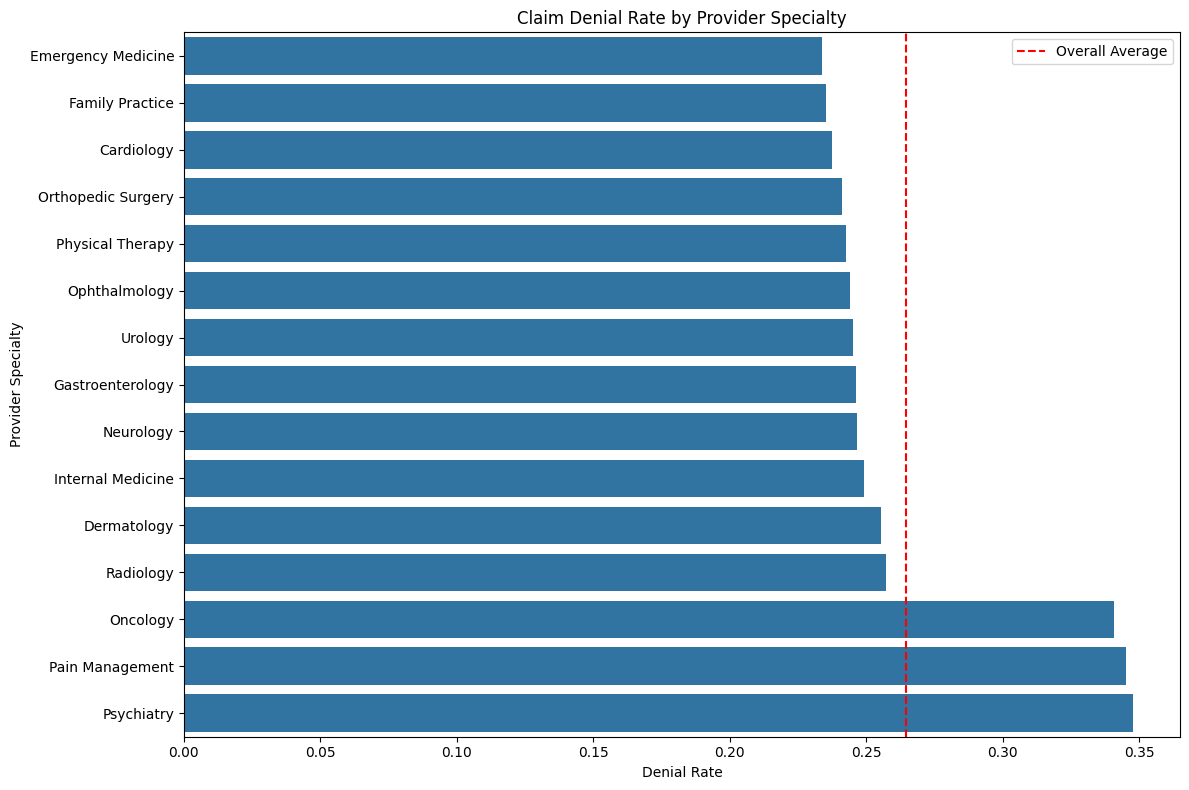

In [19]:
denial_by_specialty = (df_synthetic.groupby('provider_specialty')['is_denied']
                         .mean()
                         .sort_values(ascending=True)
                         .reset_index())

denial_by_specialty.columns = ['provider_specialty', 'denial_rate']

plt.figure(figsize=(12, 8))
sns.barplot(data=denial_by_specialty, x='denial_rate', y='provider_specialty')
plt.title('Claim Denial Rate by Provider Specialty')
plt.xlabel('Denial Rate')
plt.ylabel('Provider Specialty')
plt.axvline(x=df_synthetic['is_denied'].mean(), color='red', 
            linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

## Chart 1 Insight
The three highest denial rate specialties are Psychiatry, Pain Management, 
and Oncology — all significantly above the overall average (red dashed line 
at ~26%). This is consistent with real-world patterns where these specialties 
face higher scrutiny from payers due to subjective diagnosis criteria 
(psychiatry), abuse potential (pain management), and high-cost treatments 
(oncology).

All other specialties cluster just below the overall average, reflecting the 
base denial rate in the synthetic data. This pattern confirms that 
provider_specialty will be a useful predictive feature in the denial 
prediction model — specifically the high_denial_specialty flag engineered 
in Week 3.

## Chart 2 — Distribution of Billed Amounts by Denial Status
**Question:** Are denied claims associated with higher billing amounts?
**Data source:** Synthetic claims dataset

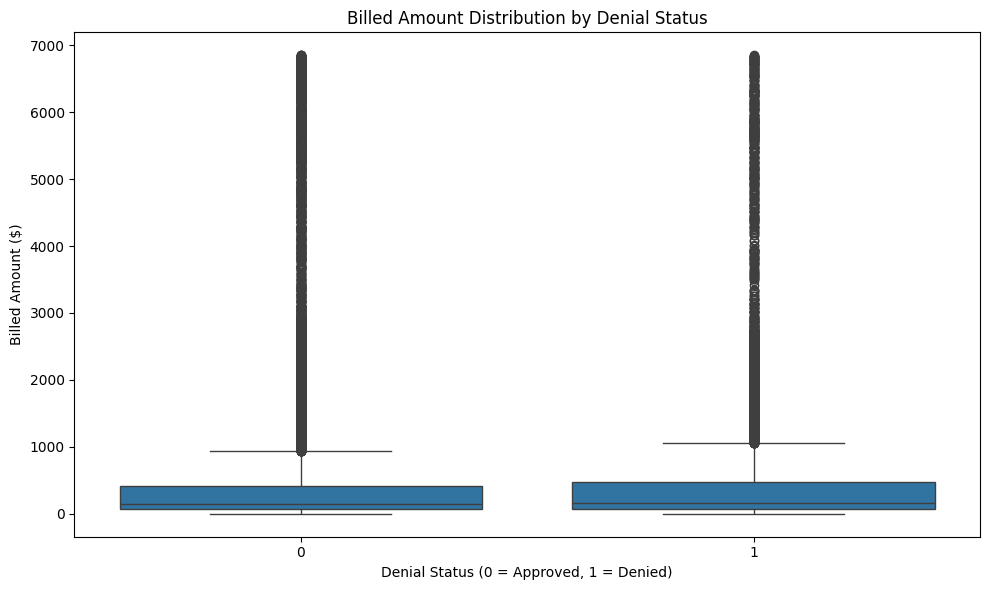

In [22]:
plt.figure(figsize=(10, 6))

# Cap at 95th percentile
cap = df_synthetic['billed_amount'].quantile(0.95)
df_plot = df_synthetic[df_synthetic['billed_amount'] <= cap]

sns.boxplot(data=df_plot, x='is_denied', y='billed_amount')
plt.title('Billed Amount Distribution by Denial Status')
plt.xlabel('Denial Status (0 = Approved, 1 = Denied)')
plt.ylabel('Billed Amount ($)')
plt.tight_layout()
plt.show()

## Chart 2 Insight
The billed amount distributions for approved and denied claims are largely 
similar, with denied claims showing a slightly wider spread of outliers 
at the upper end. This reflects the realistic nature of the synthetic data 
— upcoding affects only ~5% of claims, so the overall distributions do not 
differ dramatically.

The key signal is not in the overall distribution but in the ratio of a 
specific claim's billed amount to the median for that CPT code. This is 
why the billed_to_median_ratio engineered feature in Week 3 is more 
informative than raw billed amount alone — it normalizes by procedure 
type before making comparisons.

## Chart 3 Insight — Top 20 HCPCS Codes by Total Services

The top code by volume is Factor VIII (antihemophilic factor), a hemophilia 
medication billed per international unit rather than per patient encounter. 
This inflates Tot_Srvcs significantly and illustrates that raw service counts 
can be misleading across different procedure types — one patient infusion can 
generate thousands of billed service units. Volume metrics should therefore 
be interpreted within procedure category context rather than as a direct 
proxy for patient encounter frequency.

Below Factor VIII, office visit and evaluation & management (E&M) codes 
dominate Medicare billing volume, consistent with expectations. "Established 
patient office visit" codes appear multiple times across different complexity 
levels, confirming that E&M codes make up the bulk of Medicare claims. This 
has two implications for synthetic data generation: E&M codes should be 
heavily weighted to reflect real-world distribution, and they represent the 
highest upcoding risk due to their frequency and multiple complexity tiers 
(billing 99214 when 99213 was appropriate is one of the most common fraud 
patterns in Medicare).

The remaining top codes include injections, therapy procedures, and contrast 
materials — reflecting Medicare's predominantly aging patient population with 
chronic conditions requiring ongoing treatment.

/var/folders/h9/49xfg8x17wl2czyg0zl1_8_m0000gn/T/ipykernel_29406/172615362.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


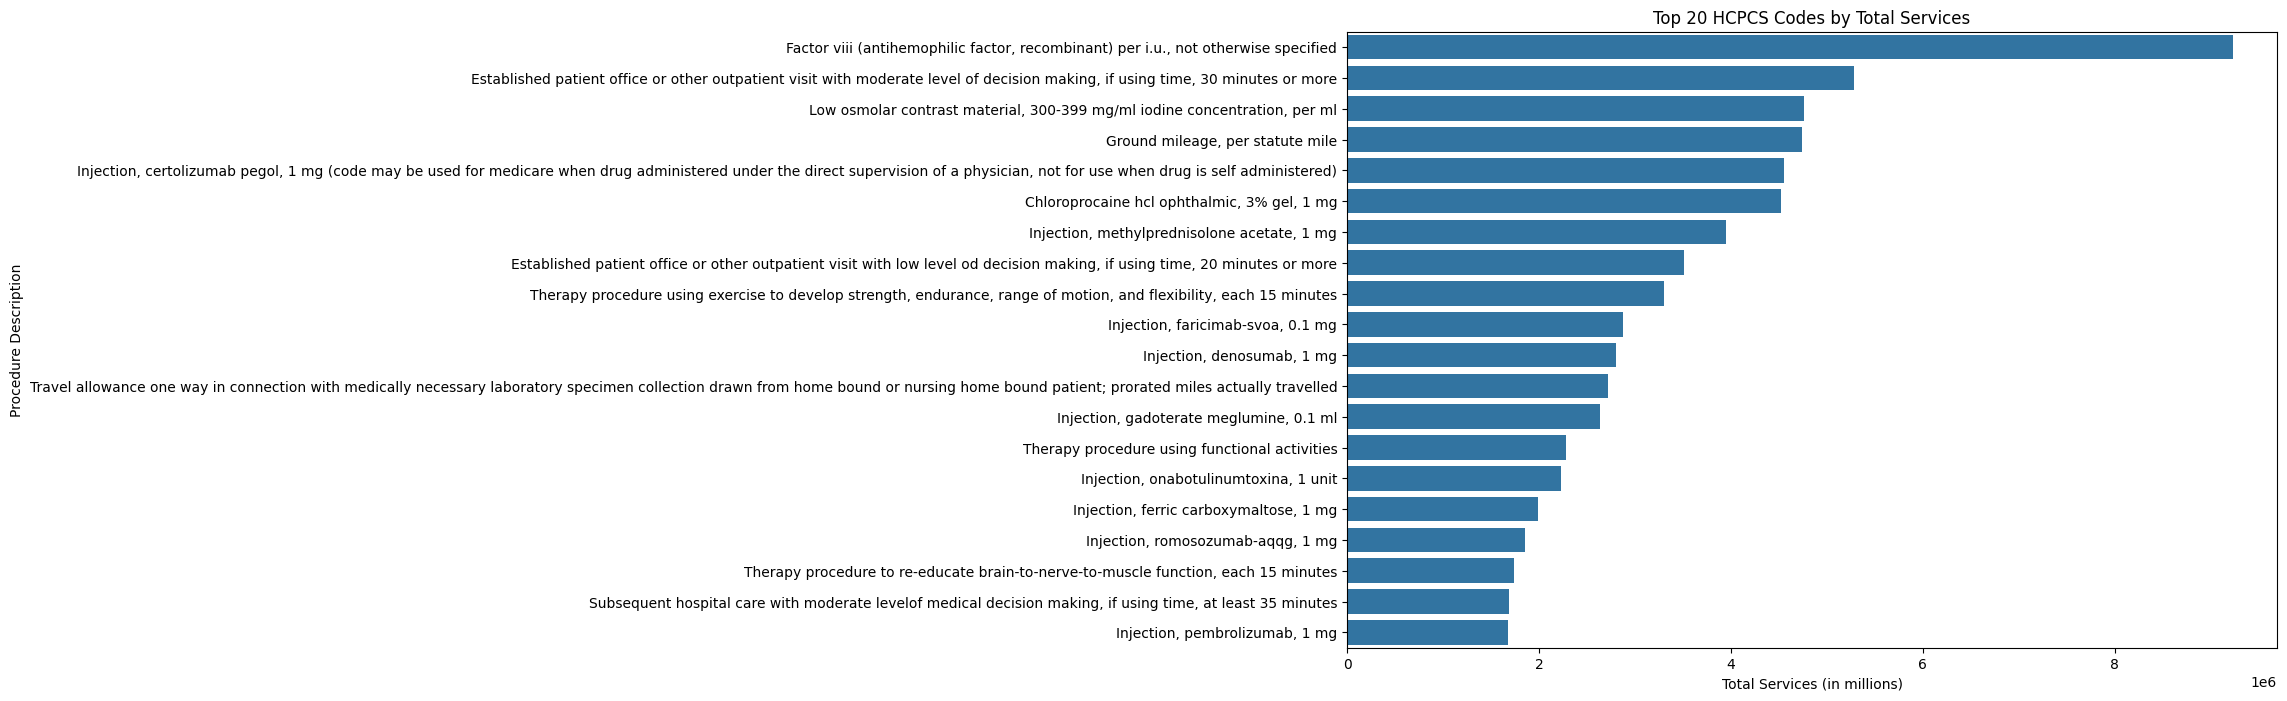

In [15]:
top20_cpt = (df.groupby(['HCPCS_Cd', 'HCPCS_Desc'])['Tot_Srvcs']
               .sum()
               .sort_values(ascending=False)
               .head(20)
               .reset_index())

plt.figure(figsize=(12, 8))
sns.barplot(data=top20_cpt, x='Tot_Srvcs', y='HCPCS_Desc')
plt.title('Top 20 HCPCS Codes by Total Services')
plt.xlabel('Total Services (in millions)')
plt.ylabel('Procedure Description')
plt.tight_layout()
plt.show()

## Chart 4 — Claim Denial Rate by ICD-10 Chapter
**Question:** Are certain disease categories more likely to be denied?
**Data source:** Synthetic claims dataset

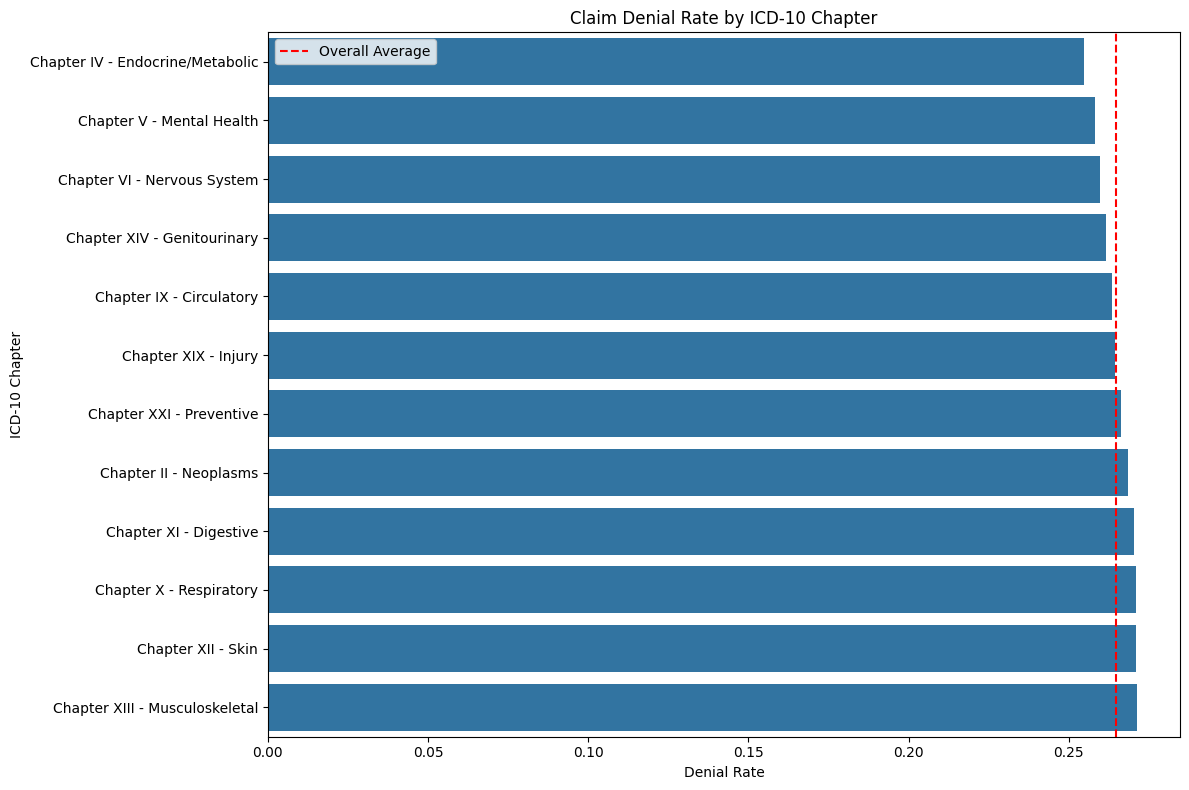

In [23]:
# Map ICD codes to chapters
icd_chapter_map = {
    'E11.9': 'Chapter IV - Endocrine/Metabolic',
    'I10': 'Chapter IX - Circulatory',
    'M54.5': 'Chapter XIII - Musculoskeletal',
    'J18.9': 'Chapter X - Respiratory',
    'F32.1': 'Chapter V - Mental Health',
    'I21.0': 'Chapter IX - Circulatory',
    'J44.1': 'Chapter X - Respiratory',
    'M17.11': 'Chapter XIII - Musculoskeletal',
    'Z23': 'Chapter XXI - Preventive',
    'N18.3': 'Chapter XIV - Genitourinary',
    'F41.1': 'Chapter V - Mental Health',
    'I50.9': 'Chapter IX - Circulatory',
    'E78.5': 'Chapter IV - Endocrine/Metabolic',
    'M79.3': 'Chapter XIII - Musculoskeletal',
    'G43.909': 'Chapter VI - Nervous System',
    'K21.0': 'Chapter XI - Digestive',
    'L40.0': 'Chapter XII - Skin',
    'F20.9': 'Chapter V - Mental Health',
    'C34.10': 'Chapter II - Neoplasms',
    'S72.001A': 'Chapter XIX - Injury'
}

df_synthetic['icd_chapter'] = df_synthetic['icd_code'].map(icd_chapter_map)

denial_by_chapter = (df_synthetic.groupby('icd_chapter')['is_denied']
                       .mean()
                       .sort_values(ascending=True)
                       .reset_index())

plt.figure(figsize=(12, 8))
sns.barplot(data=denial_by_chapter, x='is_denied', y='icd_chapter')
plt.axvline(x=df_synthetic['is_denied'].mean(), color='red',
            linestyle='--', label='Overall Average')
plt.title('Claim Denial Rate by ICD-10 Chapter')
plt.xlabel('Denial Rate')
plt.ylabel('ICD-10 Chapter')
plt.legend()
plt.tight_layout()
plt.show()

## Chart 4 Insight
ICD-10 chapters show minimal variation in denial rates, all clustering 
between 24-28% around the overall average. This reflects a limitation of 
the synthetic data generation — denial probability was not directly tied 
to ICD chapter in the generation logic, meaning the model cannot learn 
ICD-chapter-specific denial patterns from this data.

In real-world claims data, mental health (Chapter V), neoplasms (Chapter II), 
and injury (Chapter XIX) tend to have meaningfully higher denial rates due 
to medical necessity scrutiny, experimental treatment flags, and liability 
disputes respectively. A production model trained on real remittance data 
with CARC codes would capture these patterns.

This is documented as a known limitation and will be noted in the fairness 
analysis in Week 5.

## Chart 5 — Days to Submission vs Denial Rate
**Question:** Does late filing predict denial?
**Data source:** Synthetic claims dataset

/var/folders/h9/49xfg8x17wl2czyg0zl1_8_m0000gn/T/ipykernel_29406/3962622741.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denial_by_delay = (df_synthetic.groupby('filing_delay_bucket')['is_denied']


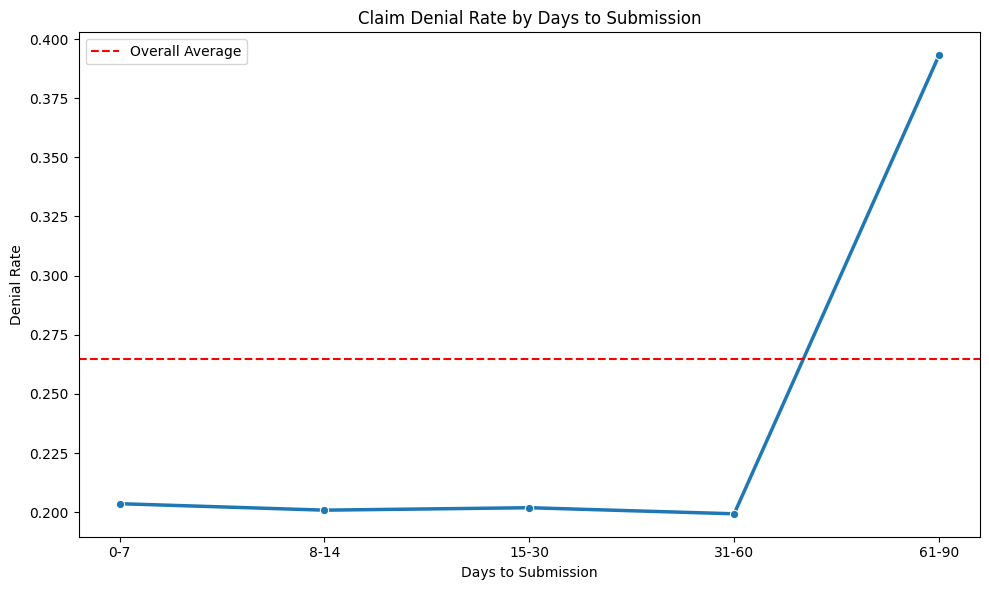

In [24]:
# Bin days to submission into buckets
bins = [0, 7, 14, 30, 60, 90]
labels = ['0-7', '8-14', '15-30', '31-60', '61-90']

df_synthetic['filing_delay_bucket'] = pd.cut(
    df_synthetic['days_to_submission'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

denial_by_delay = (df_synthetic.groupby('filing_delay_bucket')['is_denied']
                     .mean()
                     .reset_index())

plt.figure(figsize=(10, 6))
sns.lineplot(data=denial_by_delay, x='filing_delay_bucket', 
             y='is_denied', marker='o', linewidth=2.5)
plt.axhline(y=df_synthetic['is_denied'].mean(), color='red',
            linestyle='--', label='Overall Average')
plt.title('Claim Denial Rate by Days to Submission')
plt.xlabel('Days to Submission')
plt.ylabel('Denial Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Chart 5 Insight
Denial rate remains flat at approximately 20% for claims filed within 
60 days, then jumps sharply to ~39% for claims filed between 61-90 days. 
This cliff at the 60-day mark is a direct reflection of the synthetic data 
generation rule (+0.20 denial probability for days_to_submission > 60) 
rather than a gradual real-world pattern.

In real claims data this relationship would be more gradual, reflecting 
varying payer filing deadlines (typically 90-365 days depending on the 
payer). Despite being synthetic, this confirms that days_to_submission 
is a strong predictive feature and the filing_delay_bucket engineered 
in Week 3 will capture meaningful signal for the model.

# EDA Summary — Key Takeaways

## 1. Procedure Volume is Dominated by a Small Number of Codes
The top 20 HCPCS codes account for a disproportionate share of Medicare 
billing volume. Factor VIII dominates due to per-unit billing rather than 
per-encounter billing. Office visit E&M codes (99213/99214 equivalents) 
represent the most common patient encounter type and carry the highest 
upcoding risk due to multiple complexity tiers.

## 2. Specialty is a Strong Denial Predictor
Psychiatry, Pain Management, and Oncology show denial rates 8-10% above 
the overall average. All other specialties cluster near the baseline. 
This confirms provider_specialty and the high_denial_specialty flag will 
be meaningful features in the denial prediction model.

## 3. Billed Amount Alone is Not a Strong Signal
The overall distribution of billed amounts looks similar between approved 
and denied claims. The upcoding signal lives not in raw billed amount but 
in the ratio of billed amount to the CPT-code-specific median — the 
billed_to_median_ratio feature engineered in Week 3.

## 4. ICD Chapter Shows Limited Variation in Synthetic Data
All ICD chapters cluster near the overall denial rate. This is a known 
limitation of the synthetic data — denial logic was not tied to ICD chapter. 
Real-world data would show meaningful variation, particularly for mental 
health and neoplasm claims.

## 5. Late Filing is the Clearest Denial Signal
Claims filed after 60 days show a denial rate nearly double that of 
on-time claims. This is the strongest and most interpretable signal in 
the dataset and will likely be among the top features in the trained model.